# Ce notebook utilise le Machine Learning pour la détection de fraude

### Pipeline + GridSearchCV : workflow commenté et ordonné
### 1. Construction de la pipeline complète (prétraitement + modèle)
### La pipeline inclut : imputation, scaling, PCA, SMOTE, et le modèle choisi

In [40]:
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import numpy as np


Meilleurs paramètres: {'model__learning_rate': 0.2, 'model__max_depth': 3, 'model__n_estimators': 300}


In [41]:
DATA_PATH = 'fraud.csv'
ID = "Transaction_ID"
TARGET  = 'Fraudulent'

assert os.path.exists(DATA_PATH) , 'the path doesnt exist. Check it out'

data = pd.read_csv(DATA_PATH)

print(f'train shape {data.shape}')

data.tail()

train shape (51000, 12)


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [42]:
for col in data.select_dtypes(include=['object']).columns:
    print(f"Valeurs pour {col} : {data[col].unique()}")

Valeurs pour Transaction_ID : ['T1' 'T2' 'T3' ... 'T49998' 'T49999' 'T50000']
Valeurs pour Transaction_Type : ['ATM Withdrawal' 'Bill Payment' 'POS Payment' 'Bank Transfer'
 'Online Purchase']
Valeurs pour Device_Used : ['Tablet' 'Mobile' 'Desktop' nan 'Unknown Device']
Valeurs pour Location : ['San Francisco' 'New York' nan 'Chicago' 'Boston' 'Houston' 'Miami'
 'Los Angeles' 'Seattle']
Valeurs pour Payment_Method : ['Debit Card' 'Credit Card' nan 'UPI' 'Net Banking' 'Invalid Method']


In [43]:
data.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2520
Transaction_Type                       0
Time_of_Transaction                 2552
Device_Used                         2473
Location                            2547
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2469
Fraudulent                             0
dtype: int64

In [44]:
data.duplicated().sum()

np.int64(881)

In [45]:
# Deleting duplicate

In [46]:
data.drop_duplicates()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0
...,...,...,...,...,...,...,...,...,...,...,...,...
50964,T44427,1830,4187.49,Bank Transfer,4.0,Mobile,Chicago,2,67,13,NaN,0
50975,T44680,4877,1826.49,POS Payment,10.0,Desktop,Houston,1,91,4,Net Banking,0
50985,T39758,2029,544.53,Bank Transfer,14.0,Unknown Device,Chicago,4,59,12,Debit Card,0
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0


In [47]:
FEATURES_COLS = data.columns
DROP_COLS = [ID] # This array can be updated with Feature Engineering. As soon as it is not the purpose of this notebook,we shant implement it
USED_COLS = [c for c in FEATURES_COLS if c not in DROP_COLS]

In [48]:
if TARGET in FEATURES_COLS:
    classes = data[TARGET].value_counts(normalize=True).round(2)
    print(classes)

Fraudulent
0    0.95
1    0.05
Name: proportion, dtype: float64


<Axes: xlabel='Fraudulent'>

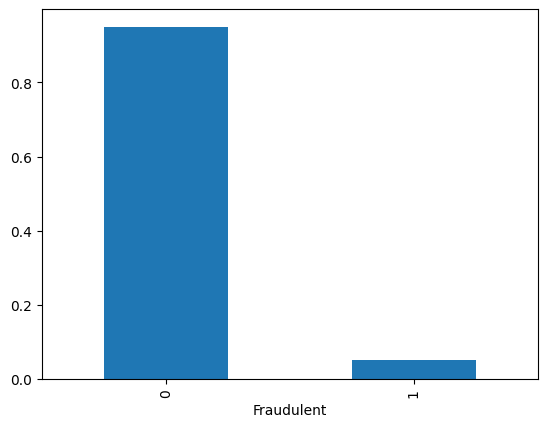

In [49]:
classes.plot(kind='bar')

# Imbalance
Fraud datasets are generally imbalanced. So we need deal with it

In [50]:
data_final = pd.get_dummies(data[USED_COLS])
data_final.columns

Index(['User_ID', 'Transaction_Amount', 'Time_of_Transaction',
       'Previous_Fraudulent_Transactions', 'Account_Age',
       'Number_of_Transactions_Last_24H', 'Fraudulent',
       'Transaction_Type_ATM Withdrawal', 'Transaction_Type_Bank Transfer',
       'Transaction_Type_Bill Payment', 'Transaction_Type_Online Purchase',
       'Transaction_Type_POS Payment', 'Device_Used_Desktop',
       'Device_Used_Mobile', 'Device_Used_Tablet',
       'Device_Used_Unknown Device', 'Location_Boston', 'Location_Chicago',
       'Location_Houston', 'Location_Los Angeles', 'Location_Miami',
       'Location_New York', 'Location_San Francisco', 'Location_Seattle',
       'Payment_Method_Credit Card', 'Payment_Method_Debit Card',
       'Payment_Method_Invalid Method', 'Payment_Method_Net Banking',
       'Payment_Method_UPI'],
      dtype='object')

In [51]:

# 1. On transforme en Dummies (Texte -> Nombres)
data_final = pd.get_dummies(data[USED_COLS])
X = data_final
y = data[TARGET]

# 2. SPLIT (Toujours avant d'imputer pour éviter la fuite de données)
X_train_dev, X_test, y_train_dev, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_dev, y_train_dev, test_size=0.2, random_state=42)

# 3. IMPUTATION (On remplit les cases vides par la médiane)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_val = imputer.transform(X_val)
X_test = imputer.transform(X_test)

# 4. SCALING (Maintenant que tout est plein, on peut scaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# 5. PCA
pca = PCA(n_components=20)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

# 6. SMOTE
smote = SMOTE(random_state=42)
X_train_final, y_train_final = smote.fit_resample(X_train_pca, y_train)


print(f"Succes! Final Format : {X_train_final.shape}")

Succes! Final Format : (65990, 20)


In [52]:
models = {
    "RandomForest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42),
    "IsolationForest": IsolationForest(),
}

In [53]:
results = {}

print("--- Évaluation des modèles ---")
for name, model in models.items():
    # We train on balance data
    model.fit(X_train_final, y_train_final)
    
    # W epredict with val(imbalanced)
    y_pred = model.predict(X_val_pca)
    
    # We get the score
    score = f1_score(y_val, y_pred,average='micro')
    results[name] = score
    print(f"{name} -> F1-Score: {score:.4f}")

# We pick up the best model
best_model_name = max(results, key=results.get)
print(f"\n The best model is: {best_model_name}")

--- Évaluation des modèles ---
RandomForest -> F1-Score: 0.9972
XGBoost -> F1-Score: 0.9983
IsolationForest -> F1-Score: 0.0413

 The best model is: XGBoost


# xgboost is the best choice

In [54]:
# Affichage de l’importance des variables (XGBoost après PCA)
importances_xgb = pipe_xgb.named_steps['model'].feature_importances_
n_pca = len(importances_xgb)
features_pca = [f'PC{i+1}' for i in range(n_pca)]
feature_importance_df_xgb = pd.DataFrame({'Feature': features_pca, 'Importance': importances_xgb})
feature_importance_df_xgb = feature_importance_df_xgb.sort_values(by='Importance', ascending=False)
print(feature_importance_df_xgb)

   Feature  Importance
18    PC19    0.588604
19    PC20    0.217297
17    PC18    0.083268
16    PC17    0.024902
9     PC10    0.019396
15    PC16    0.008418
12    PC13    0.008320
1      PC2    0.006487
11    PC12    0.005875
14    PC15    0.005567
10    PC11    0.005259
8      PC9    0.004597
5      PC6    0.004007
4      PC5    0.003805
13    PC14    0.003725
0      PC1    0.003202
6      PC7    0.002188
3      PC4    0.001838
2      PC3    0.001709
7      PC8    0.001535


In [55]:
# Optimisation des hyperparamètres du XGBoost avec GridSearchCV
params_xgb = {
    'n_estimators':[100,200,300],
    'max_depth':[3,5,7],
    'learning_rate':[0.01,0.1,0.2]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42), params_xgb, cv=5, scoring='f1')
grid_xgb.fit(X_train_final, y_train_final)
print('Meilleurs paramètres XGBoost:', grid_xgb.best_params_)

Meilleurs paramètres XGBoost: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}


In [56]:
from sklearn.metrics import classification_report
print("--- Distribution des prédictions ---")
from collections import Counter
print(Counter(y_predict))
print("\n--- Rapport de Classification ---")
print(classification_report(y_test, y_predict))

--- Distribution des prédictions ---
Counter({np.int64(0): 7265, np.int64(1): 385})

--- Rapport de Classification ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      7256
           1       0.99      0.97      0.98       394

    accuracy                           1.00      7650
   macro avg       1.00      0.98      0.99      7650
weighted avg       1.00      1.00      1.00      7650



## Saving 

In [57]:
import joblib
# Sauvegarde de la pipeline complète
joblib.dump(pipe_xgb, 'fraud_detection_pipeline_xgb.pkl')
model_columns = list(X_train_dev.columns)
joblib.dump(model_columns, 'model_columns.pkl')
print("Pipeline et colonnes sauvegardées !")

Pipeline et colonnes sauvegardées !
